# Phase 5B — Opponent-Relational Predictive Increment

This notebook reports the **saved, frozen-protocol execution**. It does not fit models. Phase 5B asks whether cutoff-fixed opponent information adds held-out predictive information beyond Phase 5A B4. Predictive increment is not tactical response, responsibility, attribution, or causation.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
out = root / 'outputs' / 'phase5b'
fig = root / 'figures' / 'phase5b'
classification = json.loads((out / 'classification.json').read_text())
qc = json.loads((out / 'qc_results.json').read_text())
assert qc['passed'] and not qc['metrica_game3_accessed']
classification['classification']

{'category': 'B',
 'label': 'MIXED_PARTIAL',
 'best_opponent_model': 'B7',
 'A_qualifying_models': [],
 'classification_precedence': ['A', 'C', 'B'],
 'mechanically_verified': True}

## Primary held-out results

In [2]:
summary = pd.read_csv(out / 'primary_model_summary.csv')
adjacent = pd.read_csv(out / 'adjacent_materiality.csv')
display(summary)
display(adjacent)

,model,median_MAE,MAE_min,MAE_max,MAE_IQR,median_relative_improvement_vs_B4,matches_improved_vs_B4,matches_worsened_10pct_or_more_vs_B4
0,B4,2.114185,1.918618,2.232788,0.034132,0.000000,0,0
1,B5,2.109554,1.912419,2.223080,0.034081,0.003231,6,0
2,B6,2.109371,1.913057,2.221374,0.033772,0.002898,6,0
3,B7,2.104822,1.914220,2.223268,0.033671,0.004264,6,0


,prior,current,median_relative_MAE_improvement,matches_improved,matches_worsened_10pct_or_more,materiality_pass
0,B4,B5,0.003231,6,0,False
1,B5,B6,0.000265,4,0,False
2,B6,B7,0.001168,5,0,False


**Frozen result: B — mixed/partial.** B7 has the lowest median held-out MAE, but B5–B7 improve only 6/7 matches versus B4 and their median gains are below 1%. No adjacent step passes the frozen 3% materiality rule.

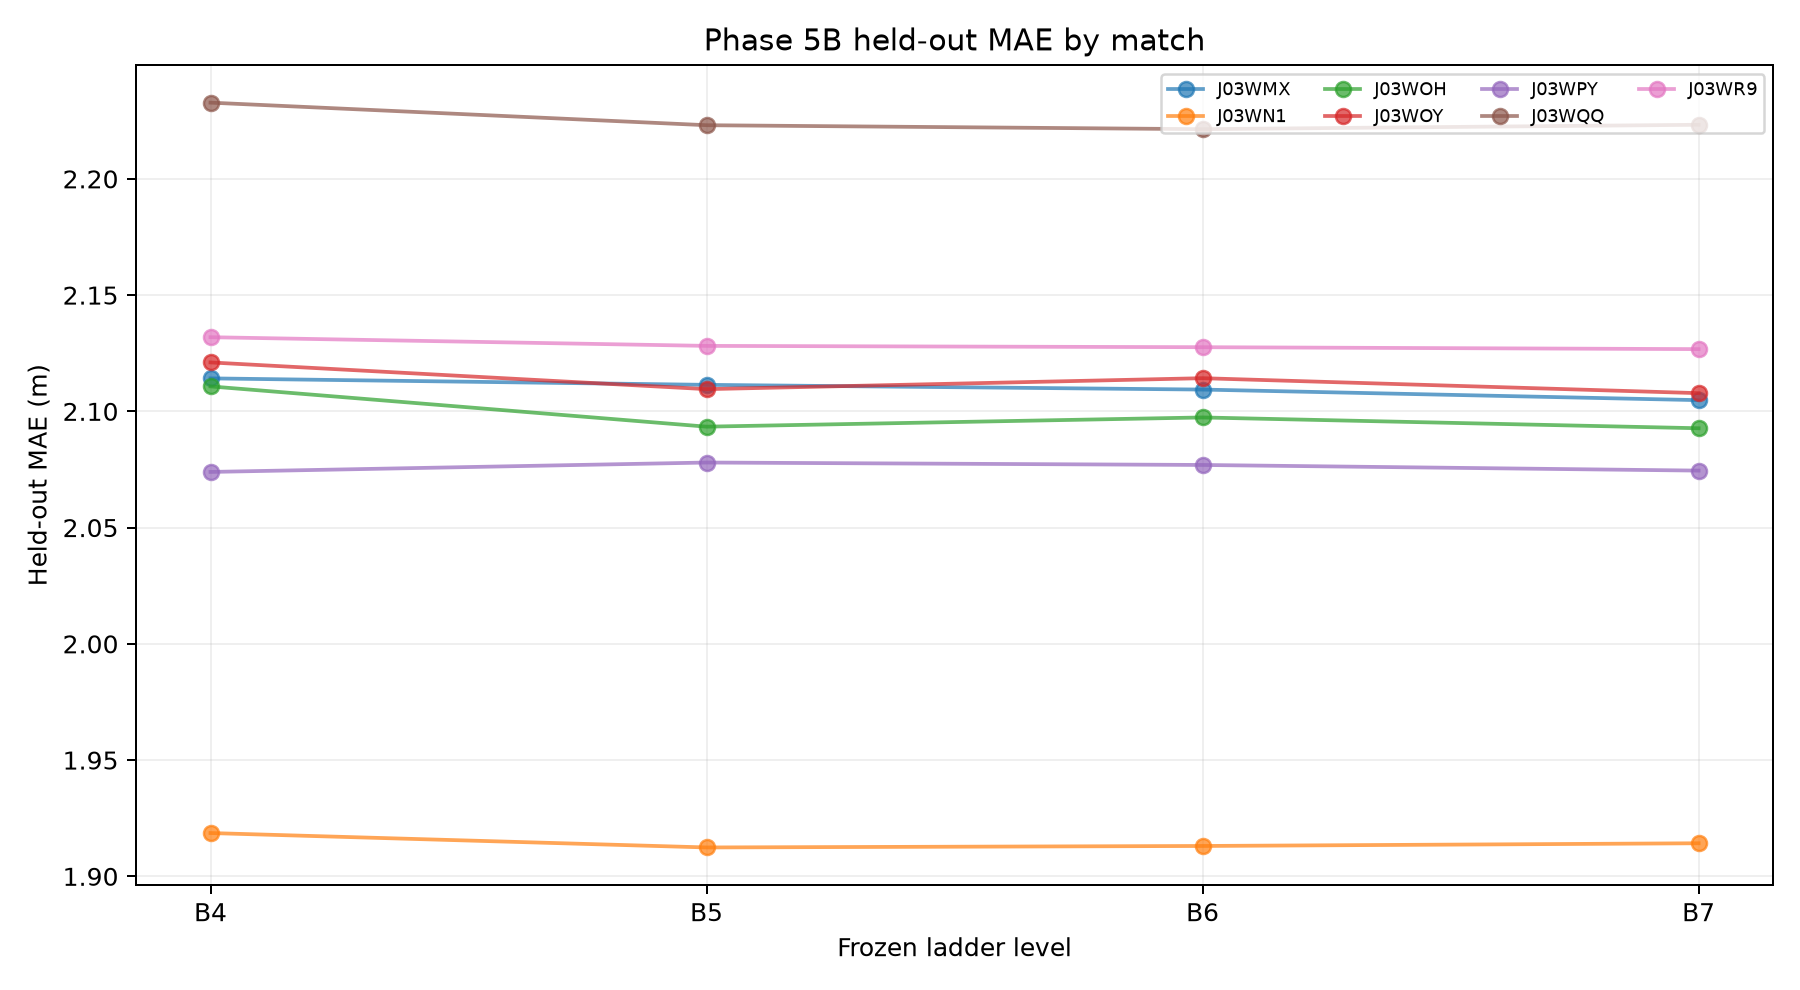

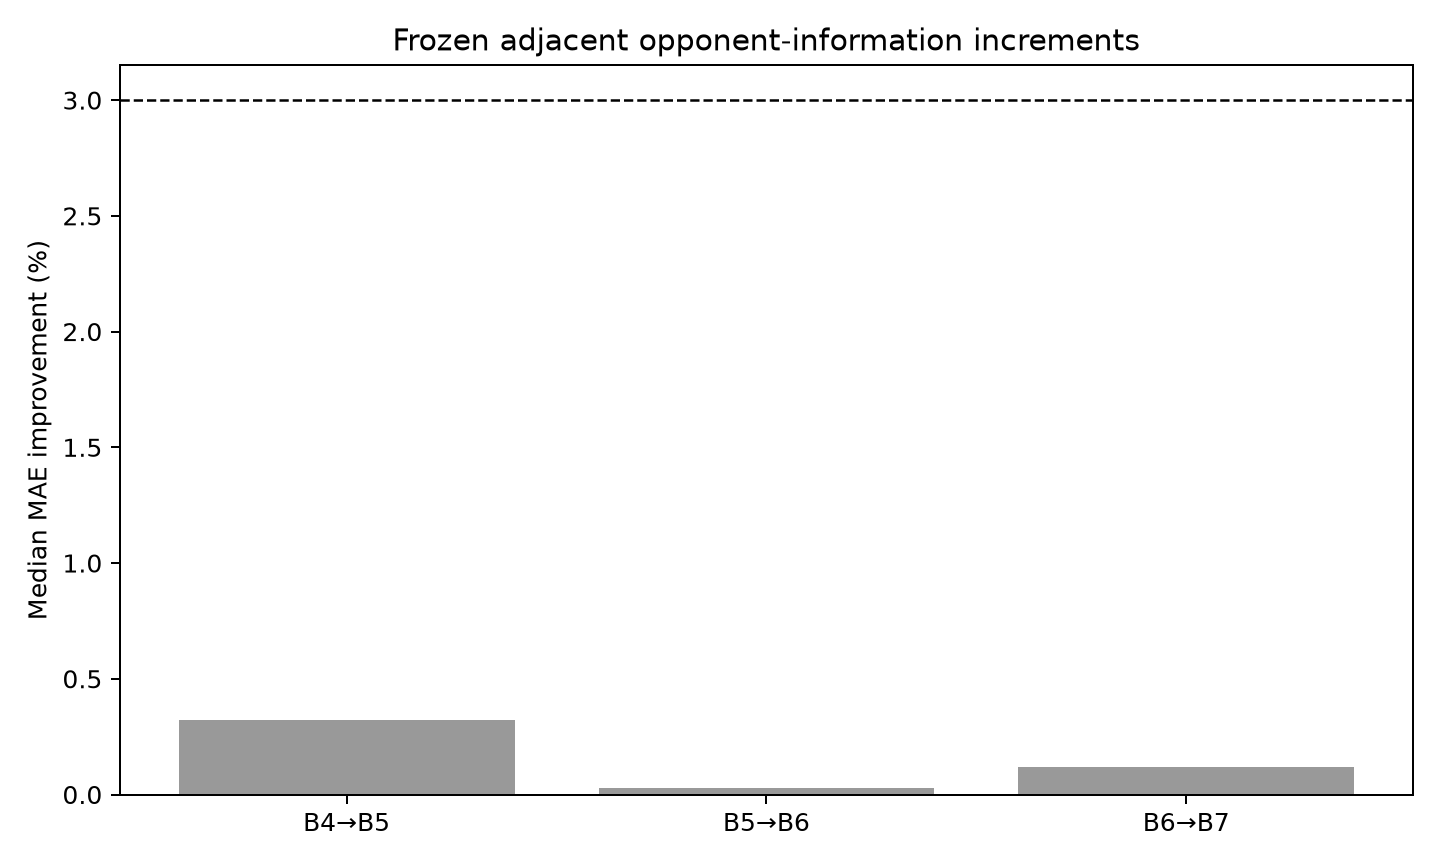

In [3]:
display(Image(filename=str(fig / 'heldout_mae_by_match.png')))
display(Image(filename=str(fig / 'adjacent_improvements.png')))

## Representation and locality controls

,model,median_MAE,MAE_min,MAE_max,MAE_IQR,median_relative_improvement_vs_B4,matches_improved_vs_B4,matches_worsened_10pct_or_more_vs_B4
0,B4,2.114185,1.918618,2.232788,0.034132,0.000000,0,0
1,K1_B5,2.113393,1.920231,2.230985,0.035077,0.000375,4,0
2,K1_B6,2.114010,1.921154,2.228752,0.034212,0.000593,4,0
3,K1_B7,2.109739,1.921786,2.229912,0.033036,0.001288,6,0


,model,median_MAE,MAE_min,MAE_max,MAE_IQR,median_relative_improvement_vs_B4,matches_improved_vs_B4,matches_worsened_10pct_or_more_vs_B4
0,B4,2.115732,1.919426,2.233377,0.033920,0.000000,0,0
1,LOCAL_B5,2.109562,1.913216,2.223589,0.034570,0.003235,6,0
2,LOCAL_B6,2.110823,1.913818,2.221888,0.033532,0.002922,6,0
3,LOCAL_B7,2.106355,1.914945,2.223822,0.033412,0.004279,6,0
4,NONLOCAL_B5,2.109884,1.905194,2.217888,0.040601,0.002764,5,0
5,NONLOCAL_B6,2.109772,1.904343,2.217573,0.041606,0.002817,5,0
6,NONLOCAL_B7,2.107900,1.905257,2.218658,0.042785,0.003702,6,0


,level,outer_heldout_match,local_MAE,nonlocal_MAE,local_minus_nonlocal_MAE,local_relative_improvement_vs_nonlocal
0,B5,J03WMX,2.112893,2.109884,0.003009,-0.001426
1,B5,J03WN1,1.913216,1.905194,0.008023,-0.004211
2,B5,J03WOH,2.093432,2.092883,0.000549,-0.000262
3,B5,J03WOY,2.109562,2.117280,-0.007719,0.003646
4,B5,J03WPY,2.078494,2.078037,0.000457,-0.000220
5,B5,J03WQQ,2.223589,2.217888,0.005701,-0.002570
6,B5,J03WR9,2.128173,2.134842,-0.006669,0.003124
7,B6,J03WMX,2.110823,2.109772,0.001051,-0.000498
8,B6,J03WN1,1.913818,1.904343,0.009475,-0.004975
9,B6,J03WOH,2.097403,2.093909,0.003494,-0.001669


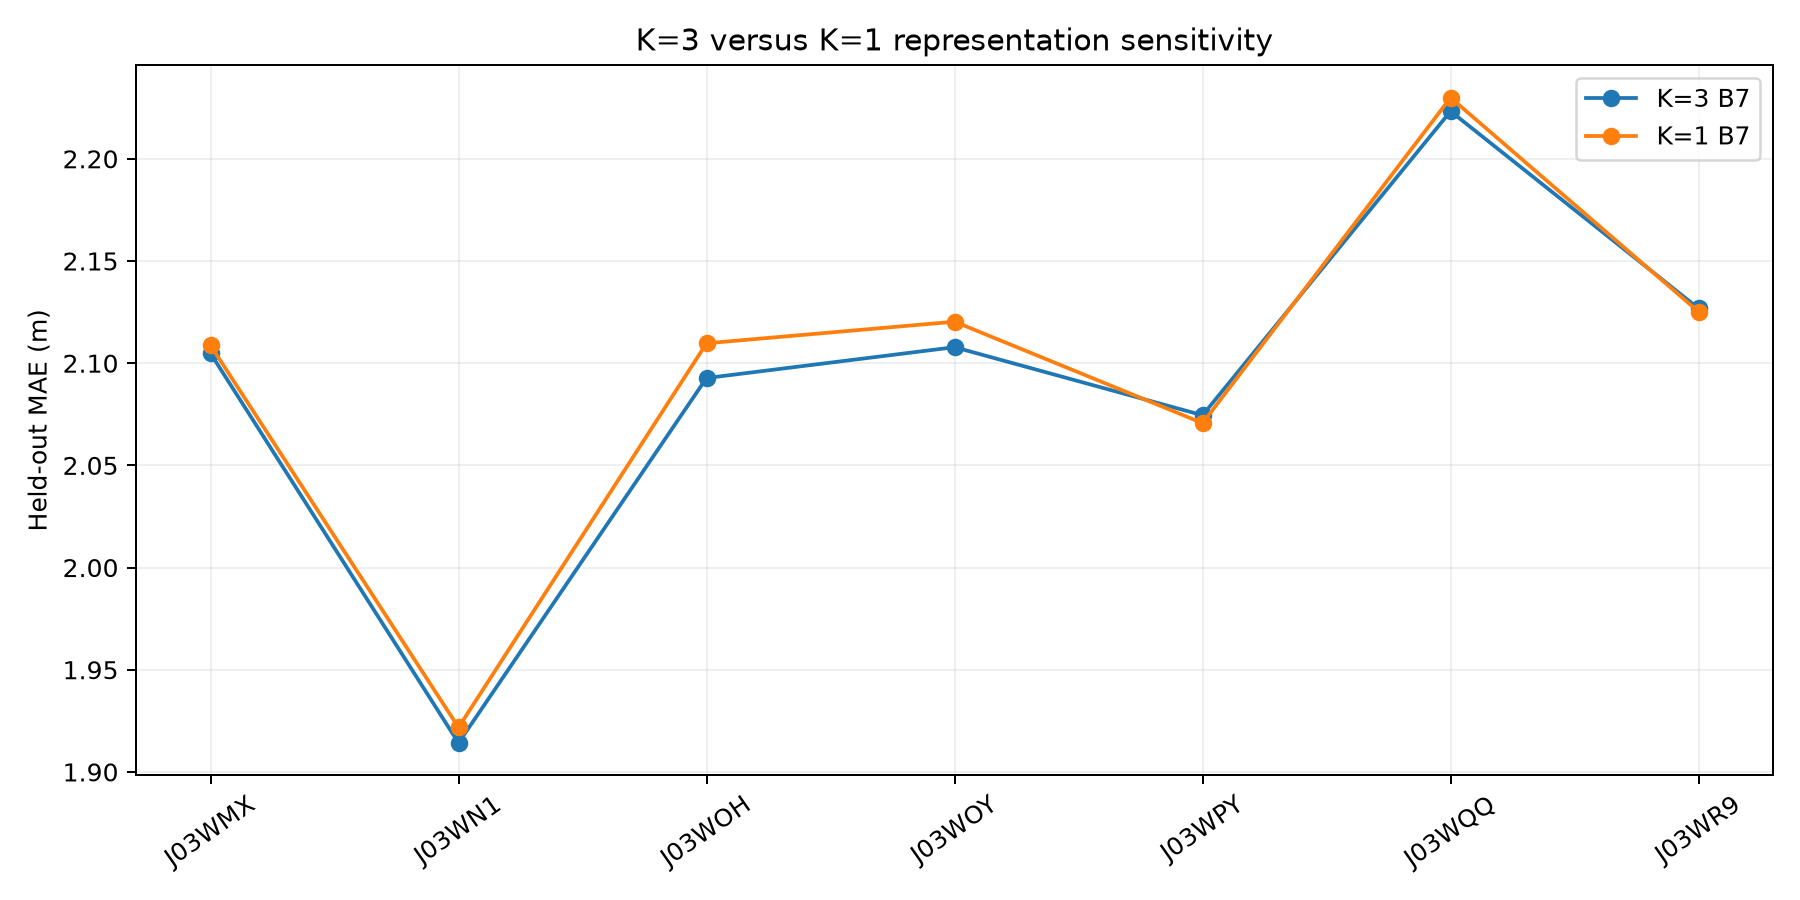

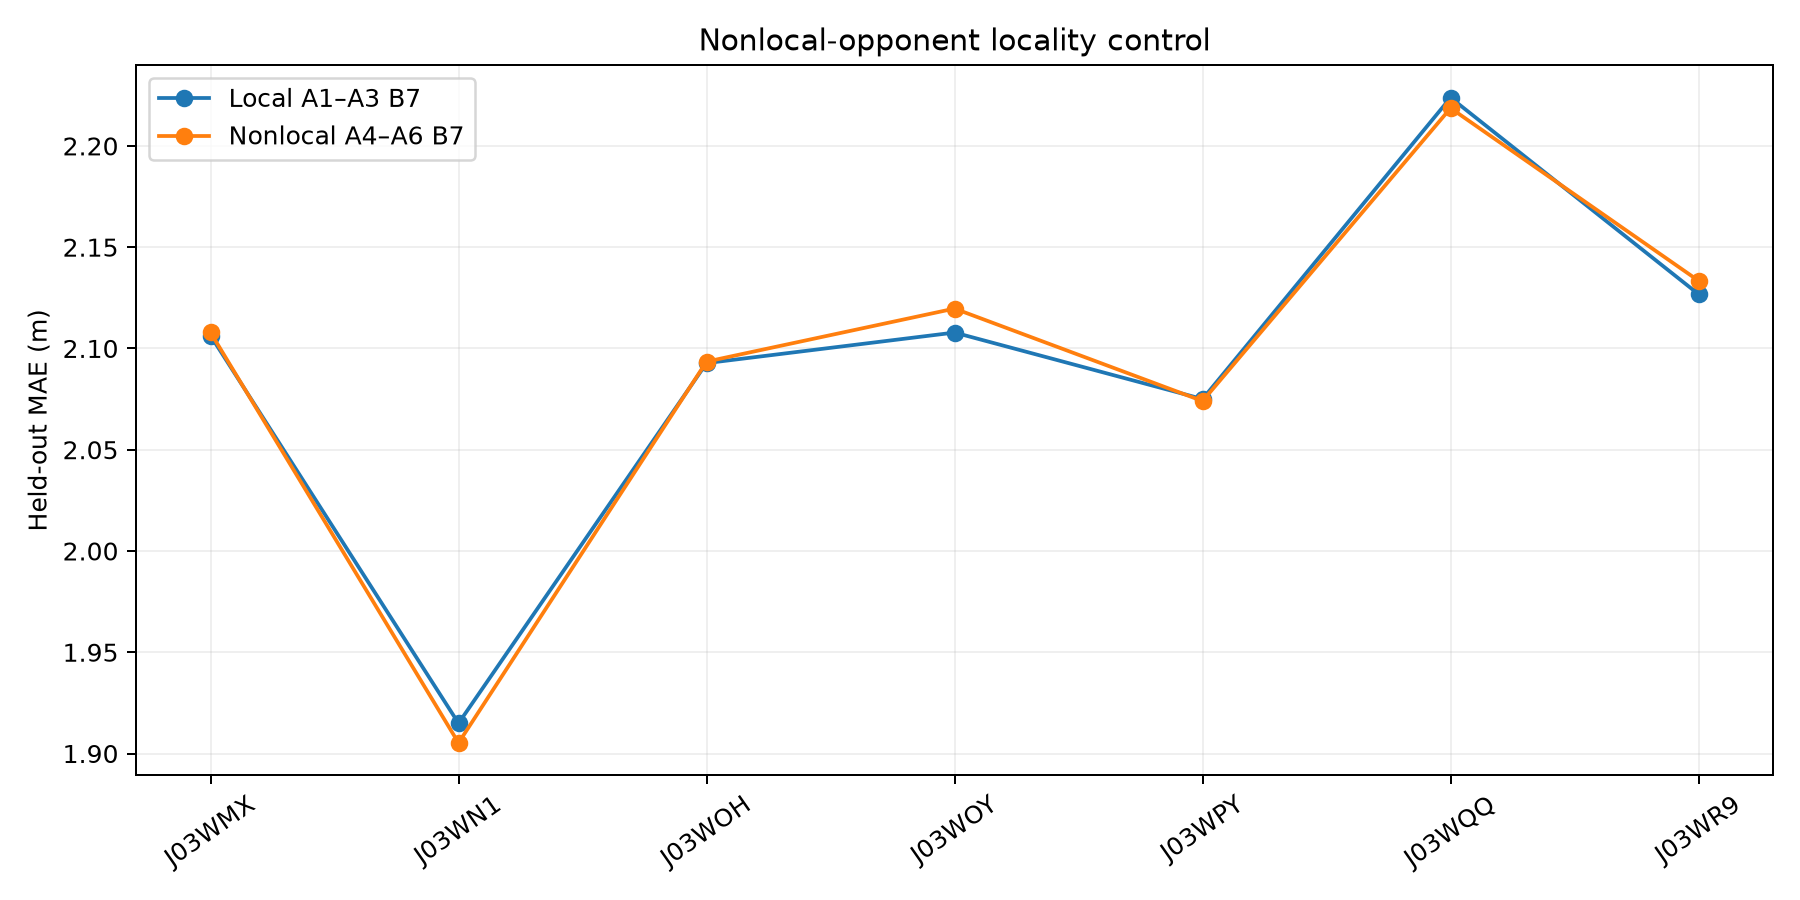

In [4]:
display(pd.read_csv(out / 'k1_model_summary.csv'))
display(pd.read_csv(out / 'locality_control_summary.csv'))
display(pd.read_csv(out / 'locality_control_comparison.csv'))
display(Image(filename=str(fig / 'k3_vs_k1.png')))
display(Image(filename=str(fig / 'local_vs_nonlocal.png')))

The fixed three-opponent representation is only slightly stronger than K=1. Local attackers do not consistently outperform nonlocal attackers. This is important counterevidence against interpreting the small predictive increment as a local opponent-specific defensive response.

## Calibration, residual diagnostics, and sensitivity

,analysis,outer_heldout_match,model,bin,realized_bins,lower_edge,upper_edge,n,predicted_mean,predicted_median,observed_mean,observed_median,calibration_slope,calibration_intercept,mean_residual
0,primary_K3_2s,J03WMX,B7,1,5,0.584059,3.924212,1223,3.218936,3.341978,2.786551,2.486962,NaN,NaN,NaN
1,primary_K3_2s,J03WMX,B7,2,5,3.924212,4.900329,1269,4.410783,4.413409,4.247307,3.879330,NaN,NaN,NaN
2,primary_K3_2s,J03WMX,B7,3,5,4.900329,5.964949,1286,5.429410,5.437067,5.621428,5.161256,NaN,NaN,NaN
3,primary_K3_2s,J03WMX,B7,4,5,5.964949,7.363108,1538,6.616916,6.600044,6.895916,6.318365,NaN,NaN,NaN
4,primary_K3_2s,J03WMX,B7,5,5,7.363108,51.152895,1630,9.028521,8.616392,8.997860,8.423160,NaN,NaN,NaN
5,primary_K3_2s,J03WMX,B7,ALL,5,NaN,NaN,6946,5.961643,5.726958,5.945778,5.141782,1.024472,-0.161761,-0.015865
6,primary_K3_2s,J03WN1,B7,1,5,0.253745,4.014124,1467,3.343923,3.447110,2.935909,2.655579,NaN,NaN,NaN
7,primary_K3_2s,J03WN1,B7,2,5,4.014124,5.030075,1434,4.497449,4.480471,4.247504,3.891024,NaN,NaN,NaN
8,primary_K3_2s,J03WN1,B7,3,5,5.030075,6.102023,980,5.539489,5.521954,5.642517,5.291293,NaN,NaN,NaN
9,primary_K3_2s,J03WN1,B7,4,5,6.102023,7.486201,785,6.720845,6.683354,7.076124,6.325967,NaN,NaN,NaN


,scope,group,diagnostic,source_column,spearman_rho,n
0,overall,ALL,B4_prediction_magnitude,predicted,-0.012184,44752
1,match,J03WMX,B4_prediction_magnitude,predicted,-0.001910,6946
2,match,J03WN1,B4_prediction_magnitude,predicted,0.023909,5434
3,match,J03WOH,B4_prediction_magnitude,predicted,-0.012994,6115
4,match,J03WOY,B4_prediction_magnitude,predicted,-0.034493,6342
...,...,...,...,...,...,...
99,match,J03WOH,focal_lateral_position,focal_y_m,-0.015271,6115
100,match,J03WOY,focal_lateral_position,focal_y_m,0.026540,6342
101,match,J03WPY,focal_lateral_position,focal_y_m,-0.017768,7070
102,match,J03WQQ,focal_lateral_position,focal_y_m,0.040204,6289


,model,median_MAE,MAE_min,MAE_max,MAE_IQR,median_relative_improvement_vs_B4,matches_improved_vs_B4,matches_worsened_10pct_or_more_vs_B4
0,B4,2.048269,1.854688,2.171132,0.053215,0.000000,0,0
1,B5,2.044129,1.848404,2.161920,0.054066,0.003388,6,0
2,B6,2.041722,1.848877,2.158511,0.053056,0.003159,6,0
3,B7,2.030175,1.851515,2.160204,0.052340,0.005033,6,0


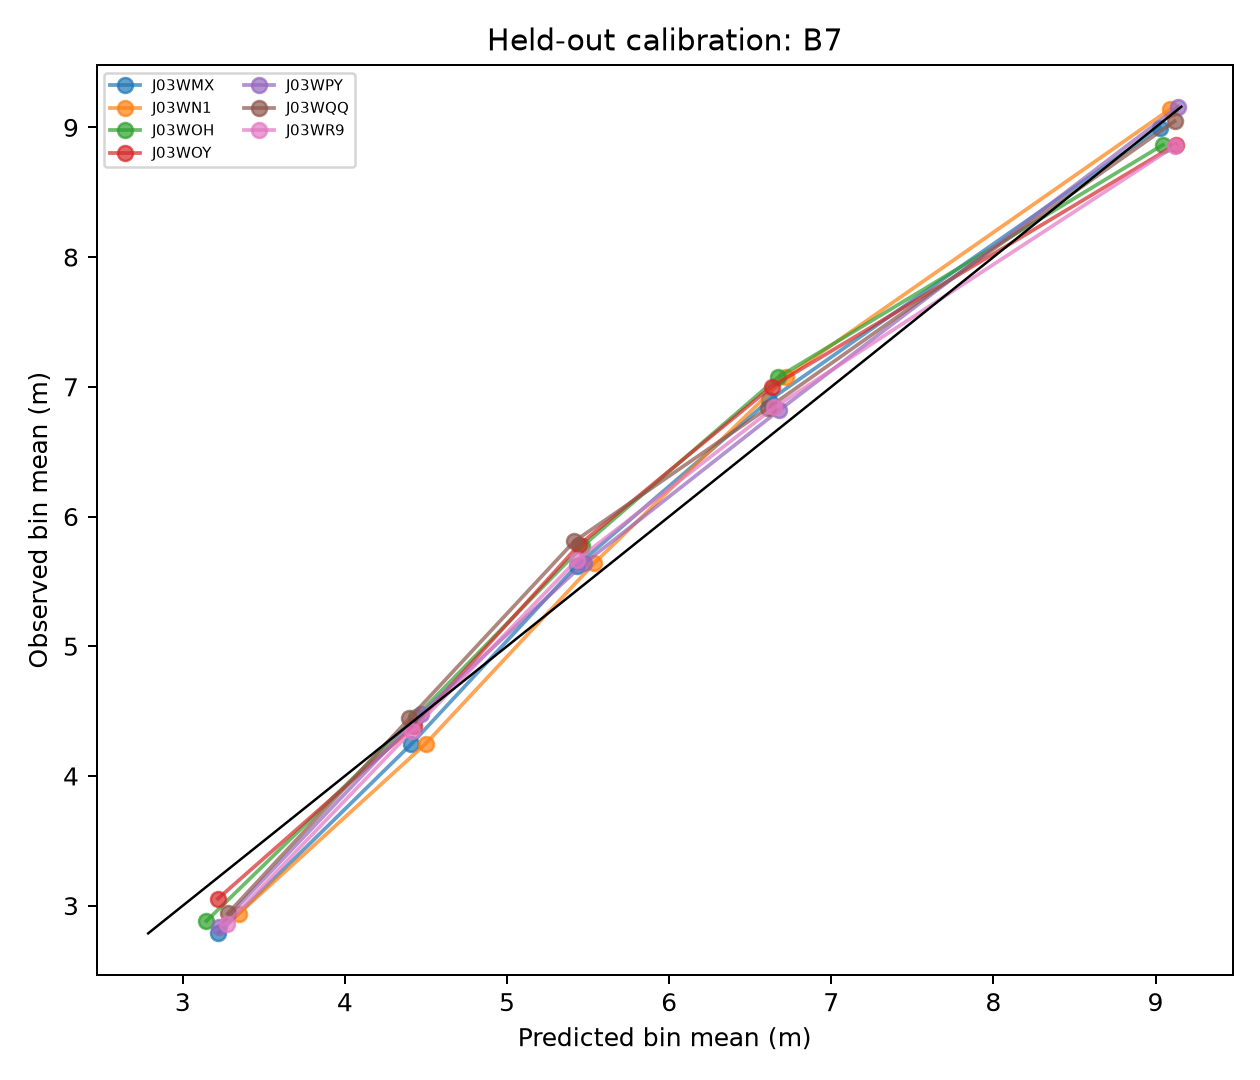

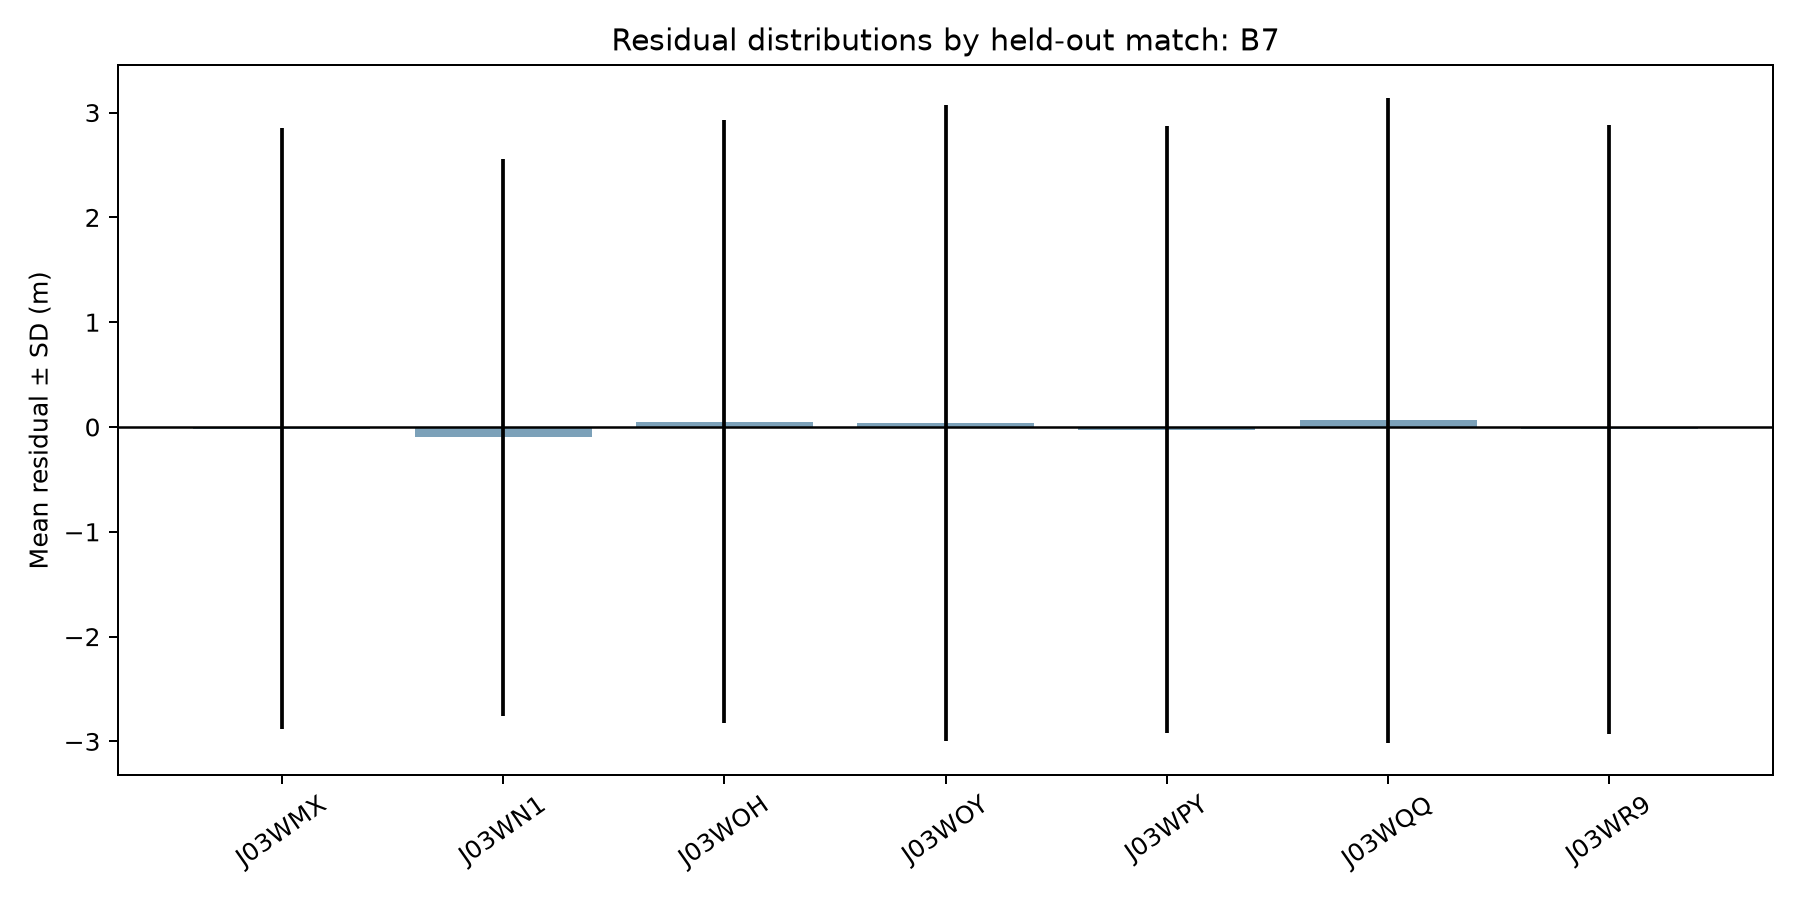

In [5]:
display(pd.read_csv(out / 'best_model_calibration.csv'))
display(pd.read_csv(out / 'residual_correlations.csv'))
display(pd.read_csv(out / 'one_second_history_summary.csv'))
display(Image(filename=str(fig / 'best_model_calibration.png')))
display(Image(filename=str(fig / 'best_model_residuals.png')))

The one-second sensitivity also classifies B and selects B7. Residual correlations are diagnostic only: residuals retain heterogeneity and are not tactical error or attacker-induced response. The maximum supported conclusion is limited to a small, mixed opponent-information association beyond B4.